# Kajiado North — Load, Clean, and Initial Analysis
This notebook loads the voter CSV, cleans key fields, filters to the Kajiado North constituency, performs basic QA, and produces summary tables and simple plots.

**Import Libraries**

In [26]:
# Cell 2: Imports and display settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
pd.options.display.max_columns = 200
pd.options.display.width = 120

OUTPUT_DIR = 'analysis_outputs'
PLOT_DIR = os.path.join('Visualizations', 'Plots')
REFERENCE_YEAR = 2026
os.makedirs(PLOT_DIR, exist_ok=True)

os.makedirs(OUTPUT_DIR, exist_ok=True)

## **Load the Dataset**

In [15]:
# Cell 3: Load raw CSV
DATA_PATH = '034 - 034.csv (1).csv'
# load everything as string first to avoid parsing problems
df_raw = pd.read_csv(DATA_PATH, dtype=str, encoding='utf-8', keep_default_na=False)
print('Rows loaded:', len(df_raw))
print('Columns:', list(df_raw.columns))
df_raw.head()

Rows loaded: 463273
Columns: ['county', 'constituency', 'caw', 'polling_center', 'polling_station', 'pstream', 'date_of_birth', 'fname', 'mname', 'sname', 'sex', 'id_passport_no']


,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no
0,KAJIADO,KAJIADO WEST,EWUASO OoNKIDONG'I,KIBIKO PRI,KIBIKO PRI,1,01/01/1949,DANIEL,KURIA,KANGACHA,Male,1066762
1,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,11,06/04/1983,ZACHEAS KAMAU,NULL,JOSEPH,Male,23566512
2,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,1,01/01/1970,ANNA NJOKI,NULL,KARANJA,Female,9831956
3,KAJIADO,KAJIADO SOUTH,KIMANA,CHRIST THE KING SEC. SCH.,CHRIST THE KING SEC. SCH.,4,01/01/1957,MARY,NJERI,GITAU,Female,370723
4,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,10,02/01/1984,SIMON MUROKI,NULL,NJOROGE,Male,24000227


### **DataSet Cleaning**

In [27]:
# Cell 4: Cleaning helpers
def clean_text_fields(df):
    text_cols = ['county','constituency','caw','polling_center','polling_station','pstream','sex']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({'NULL':'', 'None':'', 'nan':''}).str.upper()
    return df

def derive_full_name(df):
    for col in ['fname','mname','sname']:
        if col not in df.columns:
            df[col] = ''
    df['full_name'] = (df['fname'].fillna('') + ' ' + df['mname'].fillna('') + ' ' + df['sname'].fillna('')).str.replace(r'\s+', ' ', regex=True).str.strip()
    return df

def parse_birth_dates(df, reference_year=2026):
    if 'date_of_birth' in df.columns:
        df['birth_date'] = pd.to_datetime(df['date_of_birth'], dayfirst=True, errors='coerce')
        df['birth_year'] = df['birth_date'].dt.year
        df['age'] = np.where(df['birth_year'].notnull(), reference_year - df['birth_year'], np.nan)
    else:
        df['birth_date'] = pd.NaT
        df['birth_year'] = np.nan
        df['age'] = np.nan
    return df


def count_missing(df):
    return df.isin(['', ' ', None, np.nan]).sum()

### **Apply cleaning and Derive Columns**

In [17]:
# **Apply cleaning and derive columns**
df = df_raw.copy()
df = clean_text_fields(df)
df = derive_full_name(df)
df = parse_birth_dates(df)

# Standardize id column name if different
if 'id_passport_no' not in df.columns:
    if 'id' in df.columns:
        df = df.rename(columns={'id':'id_passport_no'})

print('After cleaning — sample:')
df[['constituency','caw','polling_center','polling_station','sex','birth_date','age','full_name']].head()

After cleaning — sample:


,constituency,caw,polling_center,polling_station,sex,birth_date,age,full_name
0,KAJIADO WEST,EWUASO OONKIDONG'I,KIBIKO PRI,KIBIKO PRI,MALE,1949-01-01,77.0,DANIEL KURIA KANGACHA
1,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,MALE,1983-04-06,43.0,ZACHEAS KAMAU NULL JOSEPH
2,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,FEMALE,1970-01-01,56.0,ANNA NJOKI NULL KARANJA
3,KAJIADO SOUTH,KIMANA,CHRIST THE KING SEC. SCH.,CHRIST THE KING SEC. SCH.,FEMALE,1957-01-01,69.0,MARY NJERI GITAU
4,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,MALE,1984-01-02,42.0,SIMON MUROKI NULL NJOROGE


In [18]:
# Reusable audit function for future voter register updates
def audit_voter_register(df, constituency='KAJIADO NORTH', output_dir=OUTPUT_DIR, reference_year=REFERENCE_YEAR):
    df = df.copy()
    df = clean_text_fields(df)
    df = derive_full_name(df)
    df = parse_birth_dates(df, reference_year=reference_year)

    if 'id_passport_no' not in df.columns and 'id' in df.columns:
        df = df.rename(columns={'id': 'id_passport_no'})

    mask = df['constituency'].fillna('').str.upper() == constituency
    df_kn = df[mask].copy()

    if 'id_passport_no' in df_kn.columns:
        df_kn['id_passport_no'] = df_kn['id_passport_no'].astype(str).str.strip().replace({'': np.nan, 'NONE': np.nan, 'NULL': np.nan})
        dup_mask = df_kn['id_passport_no'].notna() & df_kn['id_passport_no'].duplicated(keep=False)
        duplicate_ids = df_kn.loc[dup_mask, 'id_passport_no'].value_counts()
    else:
        duplicate_ids = pd.Series(dtype=int)

    if 'age' in df_kn.columns:
        df_kn['age_flag'] = np.where(df_kn['age'].isna(), 'MISSING',
                                     np.where(df_kn['age'] < 18, 'UNDERAGE',
                                              np.where(df_kn['age'] > 120, 'UNLIKELY', 'VALID')))
    else:
        df_kn['age_flag'] = 'UNKNOWN'

    valid_age_mask = df_kn['age_flag'] == 'VALID'
    bins = [0,17,24,34,44,54,64,200]
    labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
    df_kn['age_band'] = 'INVALID'
    if valid_age_mask.any():
        df_kn.loc[valid_age_mask, 'age_band'] = pd.cut(df_kn.loc[valid_age_mask, 'age'], bins=bins, labels=labels, include_lowest=True).astype(str)
    df_kn['age_band'] = pd.Categorical(df_kn['age_band'], categories=labels + ['INVALID'])

    polling_summary = (
        df_kn
        .groupby(['caw','polling_station'], dropna=False)
        .agg(
            total_records=('id_passport_no', 'size'),
            unique_ids=('id_passport_no', lambda s: s.dropna().nunique()),
            missing_id=('id_passport_no', lambda s: s.isna().sum()),
            valid_age=('age_flag', lambda s: (s == 'VALID').sum()),
            underage=('age_flag', lambda s: (s == 'UNDERAGE').sum()),
            unlikely_age=('age_flag', lambda s: (s == 'UNLIKELY').sum()),
            missing_age=('age_flag', lambda s: (s == 'MISSING').sum())
        )
        .sort_values('total_records', ascending=False)
        .reset_index()
    )

    sex_age_ct = None
    pivot = None
    if 'sex' in df_kn.columns:
        sex_age_ct = pd.crosstab(df_kn['age_band'], df_kn['sex'], margins=True, dropna=False)
        pivot = df_kn.pivot_table(index=['caw','polling_station'], columns=['age_band','sex'], values='id_passport_no', aggfunc='count', fill_value=0)

    return {
        'df_kn': df_kn,
        'duplicate_ids': duplicate_ids,
        'polling_summary': polling_summary,
        'sex_age_ct': sex_age_ct,
        'pivot': pivot,
    }


In [19]:
# Run the new audit helper on the current dataset
current_audit = audit_voter_register(df)

print('Duplicate IDs in Kajiado North:', current_audit['duplicate_ids'].sum())
if not current_audit['duplicate_ids'].empty:
    print('Top duplicate IDs:')
    print(current_audit['duplicate_ids'].head(10).to_string())

print('\nPolling station summary size:', len(current_audit['polling_summary']))
if current_audit['sex_age_ct'] is not None:
    print('\nSex-by-age-band cross-tab sample:')
    display(current_audit['sex_age_ct'].head(10))

with open(os.path.join(OUTPUT_DIR, 'kajiado_north_audit_summary.txt'), 'w', encoding='utf-8') as f:
    f.write(f"Duplicate ID count: {current_audit['duplicate_ids'].sum()}\n")
    f.write('Polling station summary rows: ' + str(len(current_audit['polling_summary'])) + '\n')
    if current_audit['sex_age_ct'] is not None:
        f.write('Sex-by-age-band cross-tab saved.\n')

print('Audit summary saved to', os.path.join(OUTPUT_DIR, 'kajiado_north_audit_summary.txt'))


Duplicate IDs in Kajiado North: 58
Top duplicate IDs:
id_passport_no
23455708    2
12651035    2
24413295    2
30174665    2
33288076    2
28649263    2
34143632    2
28162036    2
24182307    2
21787609    2

Polling station summary size: 34

Sex-by-age-band cross-tab sample:


sex,FEMALE,MALE,All
age_band,,,
<18,0,0,0
18-24,690,759,1449
25-34,15380,16748,32128
35-44,23457,23411,46868
45-54,13850,15329,29179
55-64,6695,8165,14860
65+,4931,5444,10375
INVALID,13,8,21
All,65016,69864,134880


Audit summary saved to analysis_outputs\kajiado_north_audit_summary.txt


**Filter To Kajiado North Constituency**

In [20]:
# Filter to Kajiado North and quick QA

const_name = 'KAJIADO NORTH'
mask = df['constituency'].fillna('').str.upper() == const_name
df_kn = df[mask].copy()
print('Total records in Kajiado North:', len(df_kn))

# Missing value counts (top fields)
print('\nMissing counts (Kajiado North subset):')
print(count_missing(df_kn)[['date_of_birth','sex','id_passport_no']].to_string())

# Duplicate national ID / passport records
if 'id_passport_no' in df_kn.columns:
    df_kn['id_passport_no'] = df_kn['id_passport_no'].astype(str).str.strip().replace({'': np.nan, 'NONE': np.nan, 'NULL': np.nan})
    dup_mask = df_kn['id_passport_no'].notna() & df_kn['id_passport_no'].duplicated(keep=False)
    dup_ids = df_kn.loc[dup_mask, 'id_passport_no'].value_counts()
    duplicate_count = dup_ids.sum()
    print('\nDuplicate id_passport_no count:', duplicate_count)
    if duplicate_count:
        print('Duplicate id groups (top 20):')
        print(dup_ids.head(20).to_string())
        display(
            df_kn.loc[dup_mask, ['id_passport_no','county','constituency','caw','polling_center','polling_station','sex','age']]
            .sort_values(['id_passport_no','caw','polling_station'])
            .head(20)
        )
else:
    duplicate_count = 0

# Age distribution quick stats and implausible age audit
if 'age' in df_kn.columns:
    df_kn['age_flag'] = np.where(df_kn['age'].isna(), 'MISSING',
                                 np.where(df_kn['age'] < 18, 'UNDERAGE',
                                          np.where(df_kn['age'] > 120, 'UNLIKELY', 'VALID')))
    invalid_age_mask = df_kn['age_flag'] != 'VALID'
    print('\nAge stats (Kajiado North, valid ages only):')
    print(df_kn.loc[~invalid_age_mask, 'age'].describe())
    print('\nAge flag counts:')
    print(df_kn['age_flag'].value_counts().to_string())
    if invalid_age_mask.any():
        print('\nSample implausible age records:')
        display(df_kn.loc[invalid_age_mask, ['id_passport_no','date_of_birth','birth_date','age','age_flag','caw','polling_station']].head(20))
else:
    df_kn['age_flag'] = 'UNKNOWN'

# Age bands (valid ages only)
valid_age_mask = df_kn['age_flag'] == 'VALID'
bins = [0,17,24,34,44,54,64,200]
labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
df_kn['age_band'] = 'INVALID'
if valid_age_mask.any():
    df_kn.loc[valid_age_mask, 'age_band'] = pd.cut(df_kn.loc[valid_age_mask, 'age'], bins=bins, labels=labels, include_lowest=True).astype(str)
df_kn['age_band'] = pd.Categorical(df_kn['age_band'], categories=labels + ['INVALID'])
print('\nAge band counts:')
print(df_kn['age_band'].value_counts().reindex(labels + ['INVALID']).fillna(0).astype(int).to_string())

# Polling-station-level summary
polling_summary = (
    df_kn
    .groupby(['caw','polling_station'], dropna=False)
    .agg(
        total_records=('id_passport_no', 'size'),
        unique_ids=('id_passport_no', lambda s: s.dropna().nunique()),
        missing_id=('id_passport_no', lambda s: s.isna().sum()),
        valid_age=('age_flag', lambda s: (s == 'VALID').sum()),
        underage=('age_flag', lambda s: (s == 'UNDERAGE').sum()),
        unlikely_age=('age_flag', lambda s: (s == 'UNLIKELY').sum()),
        missing_age=('age_flag', lambda s: (s == 'MISSING').sum())
    )
    .sort_values('total_records', ascending=False)
    .reset_index()
)
print('\nTop polling stations by record count:')
display(polling_summary.head(20))
polling_summary.to_csv(os.path.join(OUTPUT_DIR, 'kajiado_north_polling_station_summary.csv'), index=False)

# Sex-by-age-band cross-tabs
if 'sex' in df_kn.columns:
    sex_age_ct = pd.crosstab(df_kn['age_band'], df_kn['sex'], margins=True, dropna=False)
    print('\nSex-by-age-band cross-tab (Kajiado North):')
    display(sex_age_ct)
    sex_age_ct.to_csv(os.path.join(OUTPUT_DIR, 'kajiado_north_sex_age_band_crosstab.csv'))
else:
    print('\nSex column missing; cannot build sex-by-age-band cross-tab.')

# Polling station x age band x sex pivot
if 'sex' in df_kn.columns:
    pivot = (
        df_kn
        .pivot_table(index=['caw','polling_station'], columns=['age_band','sex'], values='id_passport_no', aggfunc='count', fill_value=0)
    )
    print('\nPolling station x age band x sex sample:')
    display(pivot.head(20))
    pivot.to_csv(os.path.join(OUTPUT_DIR, 'kajiado_north_polling_age_sex_pivot.csv'))
else:
    print('\nSex column missing; cannot build polling station age-sex pivot.')


Total records in Kajiado North: 134880

Missing counts (Kajiado North subset):
date_of_birth     0
sex               0
id_passport_no    0

Duplicate id_passport_no count: 58
Duplicate id groups (top 20):
id_passport_no
23455708    2
12651035    2
24413295    2
30174665    2
33288076    2
28649263    2
34143632    2
28162036    2
24182307    2
21787609    2
9271806     2
20987851    2
29657172    2
20220639    2
29208680    2
32655935    2
22038456    2
38279757    2
29719502    2
10845079    2


,id_passport_no,county,constituency,caw,polling_center,polling_station,sex,age
182079,10845079,KAJIADO,KAJIADO NORTH,NKAIMURUNYA,ONGATA ACADEMY-NEW,ONGATA ACADEMY-NEW,MALE,56.0
343384,10845079,KAJIADO,KAJIADO NORTH,NKAIMURUNYA,ONGATA ACADEMY-NEW,ONGATA ACADEMY-NEW,MALE,56.0
154381,12651035,KAJIADO,KAJIADO NORTH,NGONG,AIC PRI .SCH,AIC PRI .SCH,MALE,53.0
13576,12651035,KAJIADO,KAJIADO NORTH,NKAIMURUNYA,NAKEEL PRI.SCH,NAKEEL PRI.SCH,MALE,53.0
288783,13843789,KAJIADO,KAJIADO NORTH,OLKERI,ARAP MOI PRI .SCH,ARAP MOI PRI .SCH,MALE,50.0
321269,13843789,KAJIADO,KAJIADO NORTH,OLKERI,ARAP MOI PRI .SCH,ARAP MOI PRI .SCH,MALE,39.0
92383,20220639,KAJIADO,KAJIADO NORTH,OLKERI,LEMELEPO WATER PROJECT,LEMELEPO WATER PROJECT,FEMALE,51.0
265248,20220639,KAJIADO,KAJIADO NORTH,OLKERI,LEMELEPO WATER PROJECT,LEMELEPO WATER PROJECT,FEMALE,51.0
67012,20987851,KAJIADO,KAJIADO NORTH,NKAIMURUNYA,ONGATA ACADEMY-NEW,ONGATA ACADEMY-NEW,FEMALE,48.0
109985,20987851,KAJIADO,KAJIADO NORTH,NKAIMURUNYA,ONGATA ACADEMY-NEW,ONGATA ACADEMY-NEW,FEMALE,35.0



Age stats (Kajiado North, valid ages only):
count    134859.000000
mean         43.985755
std          12.783507
min          22.000000
25%          35.000000
50%          41.000000
75%          51.000000
max         118.000000
Name: age, dtype: float64

Age flag counts:
age_flag
VALID       134859
UNLIKELY        21

Sample implausible age records:


,id_passport_no,date_of_birth,birth_date,age,age_flag,caw,polling_station
53116,26815914,02/12/1883,1883-12-02,143.0,UNLIKELY,OLKERI,OLKERI PRI.SCH
67580,13029226,28/05/1874,1874-05-28,152.0,UNLIKELY,NKAIMURUNYA,NKAI-MURUNYA PRI.SCH
81123,1063662,24/07/1900,1900-07-24,126.0,UNLIKELY,NGONG,JUA KALI SHEDS
94446,4720268,01/01/1900,1900-01-01,126.0,UNLIKELY,ONGATA RONGAI,ONG ATA RONGAI OPEN AIR MARKET
98193,4875642,01/01/1900,1900-01-01,126.0,UNLIKELY,ONGATA RONGAI,ONG ATA RONGAI OPEN AIR MARKET
107453,24419081,22/08/1895,1895-08-22,131.0,UNLIKELY,ONGATA RONGAI,ONG ATA RONGAI OPEN AIR MARKET
108056,6447774,01/01/1857,1857-01-01,169.0,UNLIKELY,NKAIMURUNYA,ONGATA ACADEMY-NEW
134349,22788627,01/01/1905,1905-01-01,121.0,UNLIKELY,NGONG,PCEA ENCHORRO EMUNY PRI .SCH
156876,11210867,01/01/1900,1900-01-01,126.0,UNLIKELY,NGONG,JUA KALI SHEDS
179335,20380111,01/01/1900,1900-01-01,126.0,UNLIKELY,NKAIMURUNYA,NKAI-MURUNYA MIXED DAY SEC-NEW



Age band counts:
age_band
<18            0
18-24       1449
25-34      32128
35-44      46868
45-54      29179
55-64      14860
65+        10375
INVALID       21

Top polling stations by record count:


,caw,polling_station,total_records,unique_ids,missing_id,valid_age,underage,unlikely_age,missing_age
0,ONGATA RONGAI,ONG ATA RONGAI OPEN AIR MARKET,18065,18065,0,18060,0,5,0
1,NKAIMURUNYA,NAKEEL PRI.SCH,9987,9987,0,9987,0,0,0
2,NGONG,PCEA ENCHORRO EMUNY PRI .SCH,9433,9431,0,9429,0,4,0
3,NKAIMURUNYA,ONGATA ACADEMY-NEW,8965,8962,0,8964,0,1,0
4,OLOOLUA,BULBUL PRI.SCH,8421,8419,0,8420,0,1,0
5,OLKERI,ARAP MOI PRI .SCH,8145,8142,0,8145,0,0,0
6,OLKERI,LEMELEPO WATER PROJECT,5684,5682,0,5684,0,0,0
7,OLKERI,LOWER MATASIA PRI.SCH,5115,5115,0,5115,0,0,0
8,OLOOLUA,OLOOLUA PRI.SCH,4738,4738,0,4738,0,0,0
9,NKAIMURUNYA,MOSOI RANGE CHIEF'S CAMP,4354,4353,0,4354,0,0,0



Sex-by-age-band cross-tab (Kajiado North):


sex,FEMALE,MALE,All
age_band,,,
<18,0,0,0
18-24,690,759,1449
25-34,15380,16748,32128
35-44,23457,23411,46868
45-54,13850,15329,29179
55-64,6695,8165,14860
65+,4931,5444,10375
INVALID,13,8,21
All,65016,69864,134880



Polling station x age band x sex sample:


age_band                                    18-24       25-34        35-44        45-54        55-64         65+       \
sex                                        FEMALE MALE FEMALE  MALE FEMALE  MALE FEMALE  MALE FEMALE MALE FEMALE MALE   
caw         polling_station                                                                                             
NGONG       ACK PRI SCH                         7   13    289   308    381   408    249   282    148  166     67   78   
            AIC PRI .SCH                       23   22    442   455    584   439    358   323    157  190    212  145   
            JUA KALI SHEDS                     10   13    322   433    472   541    252   327    144  179     78   96   
            NGONG TOWNSHIP PRI.SCH             33   30    415   506    543   618    306   446    150  268    113  178   
            PCEA ENCHORRO EMUNY PRI .SCH       53   58   1116  1134   1790  1646   1088  1039    493  434    286  292   
            PCEA NGONG HILLS SEC -NEW          12   18    145   195    145   176     87   119     50   72     18   45   
NKAIMURUNYA MOSOI RANGE CHIEF'S CAMP           10   16    454   380    938   817    542   539    214  206    127  111   
            NAKEEL PRI.SCH                     30   33   1214  1281   1971  1919    968  1129    366  513    262  301   
            NKAI-MURUNYA MIXED DAY SEC-NEW     14   20    313   378    516   594    289   373    152  189     94   81   
            NKAI-MURUNYA PRI.SCH               34   44    411   634    556   755    287   467    119  248     97  124   
            ONG ATA RONGAI PRI.SCH              6    8    377   359    577   562    256   412    115  194    114  128   
            ONGATA ACADEMY-NEW                 36   29   1009   958   1820  1491   1196   968    491  497    234  235   
OLKERI      ARAP MOI PRI .SCH                  27   31    847   995   1242  1275    899   945    516  598    373  397   
            DELIVERANCE CHURCH - KANDISI       11    9    166   184    234   272    188   188    115  118    106  116   
            ESILANKE WATER PROJECT              8    7    126   165    276   234    196   182    112  118    123  143   
            KISERIAN PRI.SCH                   21   21    260   272    279   292    156   176     80  130     47   58   
            LEMELEPO WATER PROJECT             15   21    634   564    907   890    615   720    364  465    213  276   
            LOWER MATASIA PRI.SCH              18   24    561   637    876   805    573   547    289  334    223  228   
            MERISHO AP CAMP-NEW                 5    3    134   131    157   149    117   105     75   74    105   80   
            NALEPO NUR SCH                      1    1     34    42     43    35     26    25     24   17     21   18   

age_band                                   INVALID       
sex                                         FEMALE MALE  
caw         polling_station                              
NGONG       ACK PRI SCH                          0    0  
            AIC PRI .SCH                         1    0  
            JUA KALI SHEDS                       1    2  
            NGONG TOWNSHIP PRI.SCH               0    0  
            PCEA ENCHORRO EMUNY PRI .SCH         3    1  
            PCEA NGONG HILLS SEC -NEW            0    0  
NKAIMURUNYA MOSOI RANGE CHIEF'S CAMP             0    0  
            NAKEEL PRI.SCH                       0    0  
            NKAI-MURUNYA MIXED DAY SEC-NEW       1    0  
            NKAI-MURUNYA PRI.SCH                 1    0  
            ONG ATA RONGAI PRI.SCH               1    1  
            ONGATA ACADEMY-NEW                   0    1  
OLKERI      ARAP MOI PRI .SCH                    0    0  
            DELIVERANCE CHURCH - KANDISI         0    0  
            ESILANKE WATER PROJECT               0    0  
            KISERIAN PRI.SCH                     0    0  
            LEMELEPO WATER PROJECT               0    0  
            LOWER MATASIA PRI.SCH                0    0 

## **Summaries for Sex and CAWs Distribution**

Sex distribution:
 sex
MALE      69864
FEMALE    65016
Name: count, dtype: int64

Top 10 CAWs:
 caw
NKAIMURUNYA      33207
OLKERI           31549
ONGATA RONGAI    27576
NGONG            22738
OLOOLUA          19810
Name: count, dtype: int64


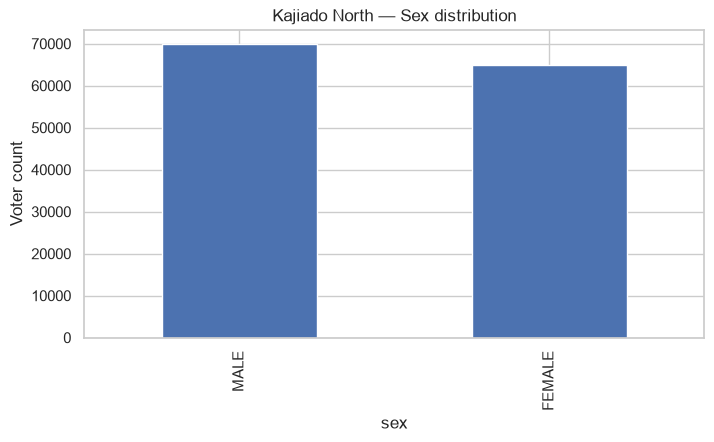

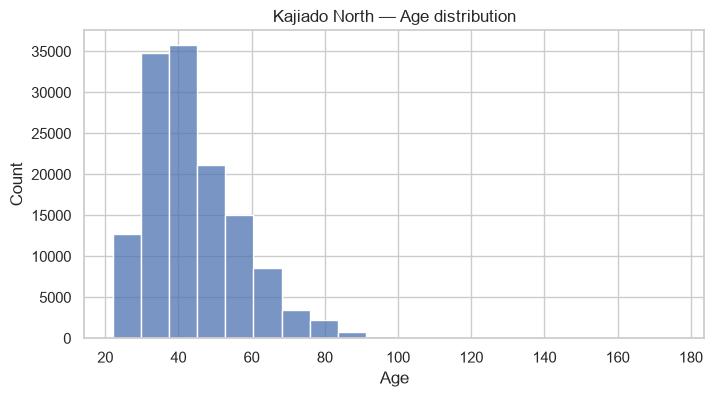

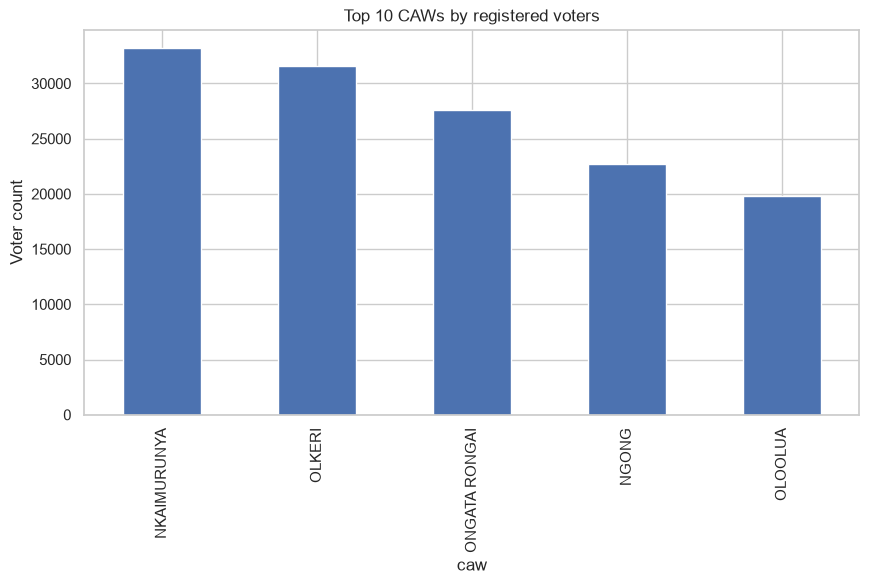

In [21]:
# Summaries and simple plots
# Sex distribution
sex_counts = df_kn['sex'].value_counts(dropna=False)
print('Sex distribution:\n', sex_counts)

# Top CAWs
if 'caw' in df_kn.columns:
    top_caws = df_kn['caw'].value_counts().head(10)
    print('\nTop 10 CAWs:\n', top_caws)

# Plots (safe: only show if non-empty)
if not sex_counts.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    sex_counts.plot(kind='bar', title='Kajiado North — Sex distribution', ax=ax)
    ax.set_ylabel('Voter count')
    fig.savefig(os.path.join(PLOT_DIR, 'kajiado_north_sex_distribution.png'), bbox_inches='tight')
    plt.show()

if 'age' in df_kn.columns and df_kn['age'].notnull().sum()>0:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(df_kn['age'].dropna(), bins=20, ax=ax)
    ax.set_title('Kajiado North — Age distribution')
    ax.set_xlabel('Age')
    fig.savefig(os.path.join(PLOT_DIR, 'kajiado_north_age_distribution.png'), bbox_inches='tight')
    plt.show()

if 'caw' in df_kn.columns and not top_caws.empty:
    fig, ax = plt.subplots(figsize=(10,5))
    top_caws.plot(kind='bar', ax=ax)
    ax.set_title('Top 10 CAWs by registered voters')
    ax.set_ylabel('Voter count')
    plt.show()
    fig.savefig(os.path.join(PLOT_DIR, 'kajiado_north_top_caws.png'), bbox_inches='tight')


## **Comparative Analysis for Kajiado North vs the rest of Kajiado**

In [22]:
# Analysis continuation: Kajiado North vs rest of Kajiado County
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATA_PATH = r"c:\Users\chris\OneDrive\Documents\Kajiado North Voter Analysis\Kajiado_North_Voter_Analysis\034 - 034.csv (1).csv"
OUTPUT_DIR = "analysis_outputs"
PLOT_DIR = os.path.join("Visualizations", "Plots")
REFERENCE_YEAR = 2026
CHUNK_SIZE = 100000
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

print('Ready: ', DATA_PATH)

Ready:  c:\Users\chris\OneDrive\Documents\Kajiado North Voter Analysis\Kajiado_North_Voter_Analysis\034 - 034.csv (1).csv


In [23]:
# Helper functions for cleaning and age derivation
import pandas as pd

def standardize_text(s):
    if pd.isna(s):
        return None
    t = str(s).strip().upper()
    return None if t in ('', 'NULL') else t


def parse_birth_year(dob):
    if pd.isna(dob):
        return None
    dt = pd.to_datetime(dob, dayfirst=True, errors='coerce')
    return int(dt.year) if not pd.isna(dt) else None


def age_from_year(year):
    if year is None:
        return None
    try:
        return REFERENCE_YEAR - int(year)
    except Exception:
        return None


def age_band(age):
    if age is None:
        return 'MISSING'
    age = int(age)
    if age < 18:
        return 'Under 18'
    if 18 <= age <= 24:
        return '18-24'
    if 25 <= age <= 34:
        return '25-34'
    if 35 <= age <= 44:
        return '35-44'
    if 45 <= age <= 54:
        return '45-54'
    if 55 <= age <= 64:
        return '55-64'
    return '65+'

print('Helpers defined')


Helpers defined


In [24]:
# Chunked processing and comparative summaries
cols = ['county','constituency','caw','polling_center','polling_station','pstream',
        'date_of_birth','fname','mname','sname','sex','id_passport_no']

county_tot = 0
north_tot = 0

from collections import Counter
sex_count_county = Counter()
sex_count_north = Counter()

age_counter_county = Counter()
age_counter_north = Counter()

ageband_county = Counter()
ageband_north = Counter()

caw_count_north = Counter()
caw_count_county = Counter()

missing_counts = Counter()

for chunk in pd.read_csv(DATA_PATH, usecols=cols, chunksize=CHUNK_SIZE, dtype=str, encoding='utf-8', low_memory=True):
    for c in ['county','constituency','caw','polling_center','polling_station','pstream','sex']:
        chunk[c] = chunk[c].apply(standardize_text)
    chunk['birth_year'] = chunk['date_of_birth'].apply(parse_birth_year)
    chunk['age'] = chunk['birth_year'].apply(age_from_year)
    chunk['age_band'] = chunk['age'].apply(age_band)

    county_tot += len(chunk)
    for col in cols:
        missing_counts[col] += chunk[col].isna().sum()

    sex_count_county.update(chunk['sex'].fillna('MISSING').tolist())
    for a in chunk['age'].dropna().astype(int).tolist():
        age_counter_county[a] += 1
    ageband_county.update(chunk['age_band'].tolist())
    caw_count_county.update(chunk['caw'].fillna('MISSING').tolist())

    north = chunk[chunk['constituency'] == 'KAJIADO NORTH']
    north_tot += len(north)
    sex_count_north.update(north['sex'].fillna('MISSING').tolist())
    for a in north['age'].dropna().astype(int).tolist():
        age_counter_north[a] += 1
    ageband_north.update(north['age_band'].tolist())
    caw_count_north.update(north['caw'].fillna('MISSING').tolist())



percent_north = north_tot / county_tot * 100 if county_tot else 0.0
print('Totals: county=', county_tot, ' KAJIADO NORTH=', north_tot)
print(f'Kajiado North as % of Kajiado County: {percent_north:.2f}%')


Totals: county= 463273  KAJIADO NORTH= 134880
Kajiado North as % of Kajiado County: 29.11%


,category,count,pct,scope
0,MALE,243125,0.524799,County
1,FEMALE,220148,0.475201,County


,category,count,pct,scope
0,MALE,69864,0.517972,Kajiado North
1,FEMALE,65016,0.482028,Kajiado North


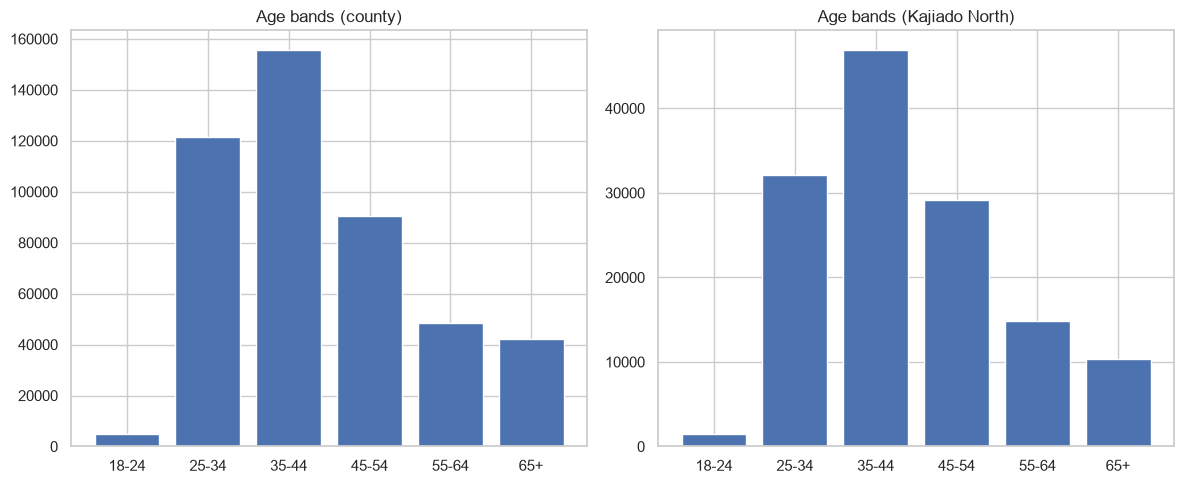

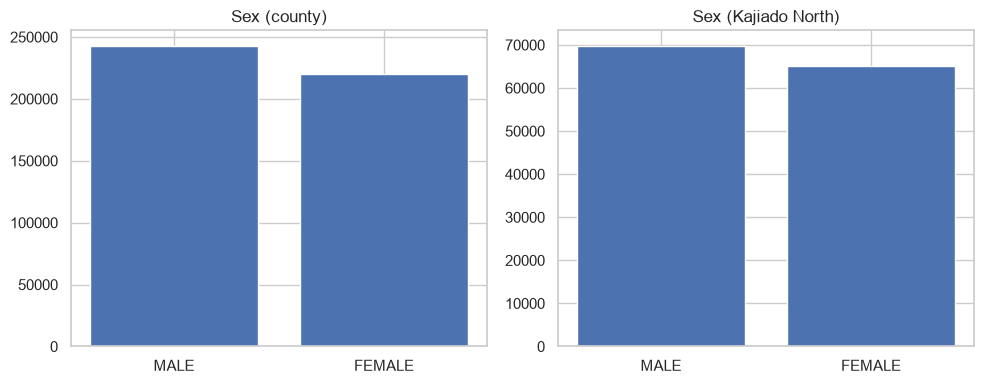

Saved summary to analysis_outputs


In [25]:
# Display sex distribution comparison as DataFrame
def to_df(counter):
    import pandas as _pd
    total = sum(counter.values())
    rows = [{'category':k, 'count':v, 'pct': v/total if total>0 else 0} for k,v in counter.most_common()]
    return _pd.DataFrame(rows)

display(to_df(sex_count_county).assign(scope='County'))
display(to_df(sex_count_north).assign(scope='Kajiado North'))

# Age band comparison plots
fig, ax = plt.subplots(1,2, figsize=(12,5))
keys_c, vals_c = zip(*sorted(ageband_county.items())) if ageband_county else ([],[])
keys_n, vals_n = zip(*sorted(ageband_north.items())) if ageband_north else ([],[])
ax[0].bar(keys_c, vals_c)
ax[0].set_title('Age bands (county)')
ax[1].bar(keys_n, vals_n)
ax[1].set_title('Age bands (Kajiado North)')
plt.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'age_band_comparison.png'), bbox_inches='tight')
plt.show()

# Sex share plots
fig2, ax2 = plt.subplots(1,2, figsize=(10,4))
kk_c, vv_c = zip(*sex_count_county.most_common()) if sex_count_county else ([],[])
kk_n, vv_n = zip(*sex_count_north.most_common()) if sex_count_north else ([],[])
ax2[0].bar(kk_c, vv_c); ax2[0].set_title('Sex (county)')
ax2[1].bar(kk_n, vv_n); ax2[1].set_title('Sex (Kajiado North)')
plt.tight_layout()
fig2.savefig(os.path.join(PLOT_DIR, 'sex_share_comparison.png'), bbox_inches='tight')
plt.show()

# Save results
with open(os.path.join(OUTPUT_DIR,'analysis_summary.txt'),'w',encoding='utf-8') as f:
    f.write(f'Reference year: {REFERENCE_YEAR}\n')
    f.write(f'Total records (county): {county_tot}\n')
    f.write(f'Total records (Kajiado North): {north_tot}\n')
    f.write('\nSex distribution (county):\n')
    for k,v in sex_count_county.most_common():
        f.write(f'{k}: {v}\n')
    f.write('\nSex distribution (Kajiado North):\n')
    for k,v in sex_count_north.most_common():
        f.write(f'{k}: {v}\n')


print('Saved summary to', OUTPUT_DIR)